<a href="https://colab.research.google.com/github/vishalraine123-rgb/CN7030-2526-T3-Machine-Learning-on-Big-Data-OC-/blob/main/week5_customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyspark


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.classification import DecisionTreeClassifier, LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Initialize Spark session
spark = SparkSession.builder \
    .appName("Logistic Regression") \
    .getOrCreate()

In [ ]:
dff = spark.read.csv('customer_segmentation_dataset.csv',inferSchema=True, header =True)

In [ ]:
dff.show(5)

+---+-------------+--------------+-----------------+-------------------+----------------+
|age|annual_income|spending_score|years_as_customer|number_of_purchases|customer_segment|
+---+-------------+--------------+-----------------+-------------------+----------------+
| 22|       113441|            19|                2|                 44|       Low Value|
| 47|        85415|            74|                7|                 11|    Medium Value|
| 60|        78075|            18|               19|                 37|       Low Value|
| 44|        89388|            84|               10|                 15|      High Value|
| 37|        94910|            85|               15|                 31|      High Value|
+---+-------------+--------------+-----------------+-------------------+----------------+
only showing top 5 rows


In [ ]:
print(dff.count())


2000000


In [ ]:
dff.select("customer_segment").distinct().show()
dff.printSchema()

+----------------+
|customer_segment|
+----------------+
|    Medium Value|
|      High Value|
|       Low Value|
+----------------+

root
 |-- age: integer (nullable = true)
 |-- annual_income: integer (nullable = true)
 |-- spending_score: integer (nullable = true)
 |-- years_as_customer: integer (nullable = true)
 |-- number_of_purchases: integer (nullable = true)
 |-- customer_segment: string (nullable = true)



In [ ]:
dff.groupBy('customer_segment').count().show()

+----------------+-------+
|customer_segment|  count|
+----------------+-------+
|    Medium Value| 505248|
|      High Value| 485871|
|       Low Value|1008881|
+----------------+-------+



In [ ]:
print("yes",dff.select("customer_segment").where("customer_segment=='yes'").count())
print("No",dff.select("customer_segment").where("customer_segment=='no'").count())

yes 0
No 0


In [ ]:
# checking the distinct values in string columns of the dataframe using functional programming
[print("column name",dff[t[0]].name,dff.select(t[0]).distinct().show()) for t in dff.dtypes if t[1]=='string' ]

+----------------+
|customer_segment|
+----------------+
|    Medium Value|
|      High Value|
|       Low Value|
+----------------+

column name <bound method Column.name of Column<'customer_segment'>> None


[None]

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression # Alias to avoid name conflict

# Convert PySpark DataFrames to NumPy arrays for scikit-learn
# Extract features (VectorUDT) and convert to dense arrays
X_train = np.array(trainingData.select("features").rdd.map(lambda row: row[0].toArray()).collect())
y_train = np.array(trainingData.select("indexedLabel").rdd.map(lambda row: row[0]).collect())

X_test = np.array(testData.select("features").rdd.map(lambda row: row[0].toArray()).collect())
# y_test (true labels for test set) is already available from previous steps

# Initialize scikit-learn Logistic Regression model
multi_skl = SklearnLogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000
)

# Train the model
multi_skl.fit(X_train, y_train)

# Make predictions
multi_pred_skl = multi_skl.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


MULTINOMIAL REGRESSION

Accuracy: 0.9898144009393367
              precision    recall  f1-score   support

   Low Value       0.99      1.00      1.00    302293
Medium Value       0.97      0.99      0.98    151421
  High Value       1.00      0.97      0.99    145858

    accuracy                           0.99    599572
   macro avg       0.99      0.99      0.99    599572
weighted avg       0.99      0.99      0.99    599572



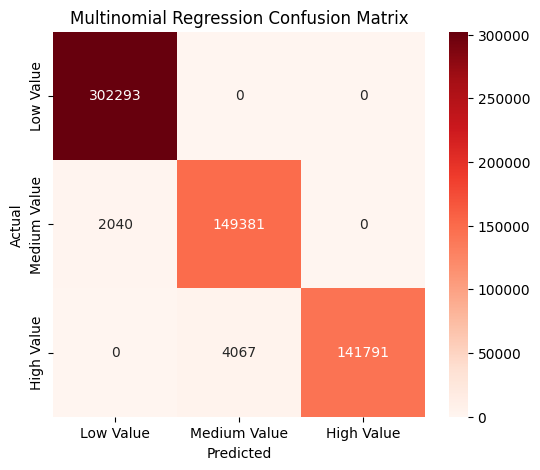

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Accuracy:",
      accuracy_score(y_test, multi_pred))

print(classification_report(
    y_test,
    multi_pred,
    target_names=labelIndexer.labels
))

# Confusion Matrix
cm_multi = confusion_matrix(y_test, multi_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_multi,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=labelIndexer.labels,
    yticklabels=labelIndexer.labels
)

plt.title('Multinomial Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

MODEL COMPARISON

In [ ]:
from sklearn.metrics import accuracy_score
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.classification import DecisionTreeClassifier, LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# 1. Feature Engineering
# Convert customer_segment to numerical labels
labelIndexer = StringIndexer(inputCol="customer_segment", outputCol="indexedLabel").fit(dff)
dff_indexed = labelIndexer.transform(dff)

# Assemble features into a vector
featureCols = ["age", "annual_income", "spending_score", "years_as_customer", "number_of_purchases"]
assembler = VectorAssembler(inputCols=featureCols, outputCol="features")
dff_assembled = assembler.transform(dff_indexed)

# 2. Split data into training and test sets
(trainingData, testData) = dff_assembled.randomSplit([0.7, 0.3], seed=42)

# Extract true labels for testing (y_test)
y_test = testData.select("indexedLabel").rdd.map(lambda row: row[0]).collect()

# 3. Train Decision Tree Model and get predictions
dt = DecisionTreeClassifier(labelCol="indexedLabel", featuresCol="features")
dt_model = dt.fit(trainingData)
dt_predictions = dt_model.transform(testData)
dt_pred = dt_predictions.select("prediction").rdd.map(lambda row: row[0]).collect()

# 4. Train Logistic Regression Model and get predictions
lr = LogisticRegression(labelCol="indexedLabel", featuresCol="features", maxIter=10)
lr_model = lr.fit(trainingData)
lr_predictions = lr_model.transform(testData)
lr_pred = lr_predictions.select("prediction").rdd.map(lambda row: row[0]).collect()

# 5. For "Multinomial Regression Accuracy", assuming another Logistic Regression model
# If a different model is intended, it would need to be imported and defined here.
multi_lr = LogisticRegression(labelCol="indexedLabel", featuresCol="features", maxIter=10)
multi_lr_model = multi_lr.fit(trainingData)
multi_lr_predictions = multi_lr_model.transform(testData)
multi_pred = multi_lr_predictions.select("prediction").rdd.map(lambda row: row[0]).collect()


print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Multinomial Regression Accuracy:",
      accuracy_score(y_test, multi_pred))

Decision Tree Accuracy: 0.979597112606993
Logistic Regression Accuracy: 0.9898144009393367
Multinomial Regression Accuracy: 0.9898144009393367
